In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Load config
with open('../models/config.json', 'r') as f:
    config = json.load(f)

device = torch.device(config['device'])

print("All imports successful!")
print(f"Device     : {device}")
print(f"PyTorch    : {torch.__version__}")

All imports successful!
Device     : mps
PyTorch    : 2.10.0


In [2]:
IMG_SIZE   = config['img_size']
BATCH_SIZE = config['batch_size']
TRAIN_DIR  = config['train_dir']
TEST_DIR   = config['test_dir']

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transforms)
test_dataset  = datasets.ImageFolder(TEST_DIR,  transform=test_transforms)

train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
test_loader   = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train batches : {len(train_loader)}")
print(f"Test batches  : {len(test_loader)}")
print("DataLoaders ready!")

Train batches : 163
Test batches  : 20
DataLoaders ready!


In [3]:
def build_resnet50(num_classes=2, freeze_layers=True):
    # Load pretrained ResNet50
    model = models.resnet50(weights='IMAGENET1K_V1')
    
    # Freeze all layers - keep ImageNet knowledge intact
    if freeze_layers:
        for param in model.parameters():
            param.requires_grad = False
    
    # Replace the final classification head with our own
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(512, num_classes)
    )
    
    return model

model = build_resnet50(num_classes=2, freeze_layers=True).to(device)

# Count trainable vs frozen parameters
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params    = total_params - trainable_params

print("ResNet50 loaded with ImageNet pretrained weights!")
print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")
print(f"Frozen parameters    : {frozen_params:,}")
print(f"\nWe only train {trainable_params/total_params*100:.1f}% of the model!")
print("The rest already knows how to detect edges, shapes and textures.")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /Users/pavankalyan/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:03<00:00, 26.7MB/s]


ResNet50 loaded with ImageNet pretrained weights!
Total parameters     : 24,558,146
Trainable parameters : 1,050,114
Frozen parameters    : 23,508,032

We only train 4.3% of the model!
The rest already knows how to detect edges, shapes and textures.


In [5]:
# Class weights to handle imbalance
class_weights = torch.tensor([3876/1342, 1342/3876]).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

# Only optimize the trainable layers (our custom head)
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.001
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=2, factor=0.5
)

print("Loss       : CrossEntropyLoss with class weights")
print("Optimizer  : Adam on trainable layers only")
print("Scheduler  : ReduceLROnPlateau (halves LR if val acc stops improving)")

Loss       : CrossEntropyLoss with class weights
Optimizer  : Adam on trainable layers only
Scheduler  : ReduceLROnPlateau (halves LR if val acc stops improving)


In [6]:
def train_resnet(model, train_loader, test_loader, criterion, optimizer, scheduler, epochs=10):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0.0

    for epoch in range(epochs):
        # Training phase
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0

        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
        for images, labels in loop:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss    += loss.item()
            _, predicted   = outputs.max(1)
            train_total   += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()
            loop.set_postfix(loss=f"{loss.item():.3f}")

        # Validation phase
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss    = criterion(outputs, labels)
                val_loss    += loss.item()
                _, predicted = outputs.max(1)
                val_total   += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        # Metrics
        train_acc      = 100 * train_correct / train_total
        val_acc        = 100 * val_correct   / val_total
        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss   = val_loss   / len(test_loader)

        history['train_loss'].append(avg_train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(val_acc)

        scheduler.step(val_acc)

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), '../models/best_resnet50.pth')
            print(f"Epoch {epoch+1}/{epochs} -> Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}% | BEST MODEL SAVED")
        else:
            print(f"Epoch {epoch+1}/{epochs} -> Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

    print(f"\nTraining complete! Best Val Accuracy: {best_val_acc:.2f}%")
    return history

print("Starting ResNet50 training...")
print("="*60)
history_resnet = train_resnet(model, train_loader, test_loader, criterion, optimizer, scheduler, epochs=10)

Starting ResNet50 training...


Epoch 1/10: 100%|██████████| 163/163 [00:32<00:00,  5.02it/s, loss=0.239]


Epoch 1/10 -> Train Acc: 77.03% | Val Acc: 82.37% | BEST MODEL SAVED


Epoch 2/10: 100%|██████████| 163/163 [00:28<00:00,  5.68it/s, loss=0.149]


Epoch 2/10 -> Train Acc: 87.44% | Val Acc: 86.54% | BEST MODEL SAVED


...

Epoch 8/10 -> Train Acc: 89.80% | Val Acc: 87.02%


Epoch 9/10: 100%|██████████| 163/163 [00:28<00:00,  5.68it/s, loss=0.209]


Epoch 9/10 -> Train Acc: 90.13% | Val Acc: 86.38%


Epoch 10/10: 100%|██████████| 163/163 [00:28<00:00,  5.68it/s, loss=0.120]


Epoch 10/10 -> Train Acc: 91.33% | Val Acc: 89.26% | BEST MODEL SAVED

Training complete! Best Val Accuracy: 89.26%


In [7]:
# Unfreeze the last ResNet block for fine-tuning
for name, param in model.named_parameters():
    if 'layer4' in name or 'fc' in name:
        param.requires_grad = True

# Lower learning rate for fine-tuning
optimizer_ft = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.0001
)

scheduler_ft = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_ft, mode='max', patience=2, factor=0.5
)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters after unfreezing: {trainable_params:,}")
print("Fine-tuning with lr=0.0001 on layer4 + fc")
print("Starting fine-tuning for 5 more epochs...")
print("="*60)

history_ft = train_resnet(model, train_loader, test_loader, criterion, optimizer_ft, scheduler_ft, epochs=5)

Trainable parameters after unfreezing: 16,014,850
Fine-tuning with lr=0.0001 on layer4 + fc
Starting fine-tuning for 5 more epochs...


Epoch 1/5: 100%|██████████| 163/163 [00:34<00:00,  4.77it/s, loss=0.217]


Epoch 1/5 -> Train Acc: 92.33% | Val Acc: 91.67% | BEST MODEL SAVED


Epoch 2/5: 100%|██████████| 163/163 [00:32<00:00,  4.98it/s, loss=0.010]


Epoch 2/5 -> Train Acc: 95.38% | Val Acc: 86.86%


...

Epoch 3/5 -> Train Acc: 95.80% | Val Acc: 84.94%


Epoch 4/5: 100%|██████████| 163/163 [00:32<00:00,  4.98it/s, loss=0.077]


Epoch 4/5 -> Train Acc: 96.45% | Val Acc: 87.98%


Epoch 5/5: 100%|██████████| 163/163 [00:32<00:00,  4.99it/s, loss=0.061]


Epoch 5/5 -> Train Acc: 97.24% | Val Acc: 84.46%

Training complete! Best Val Accuracy: 91.67%


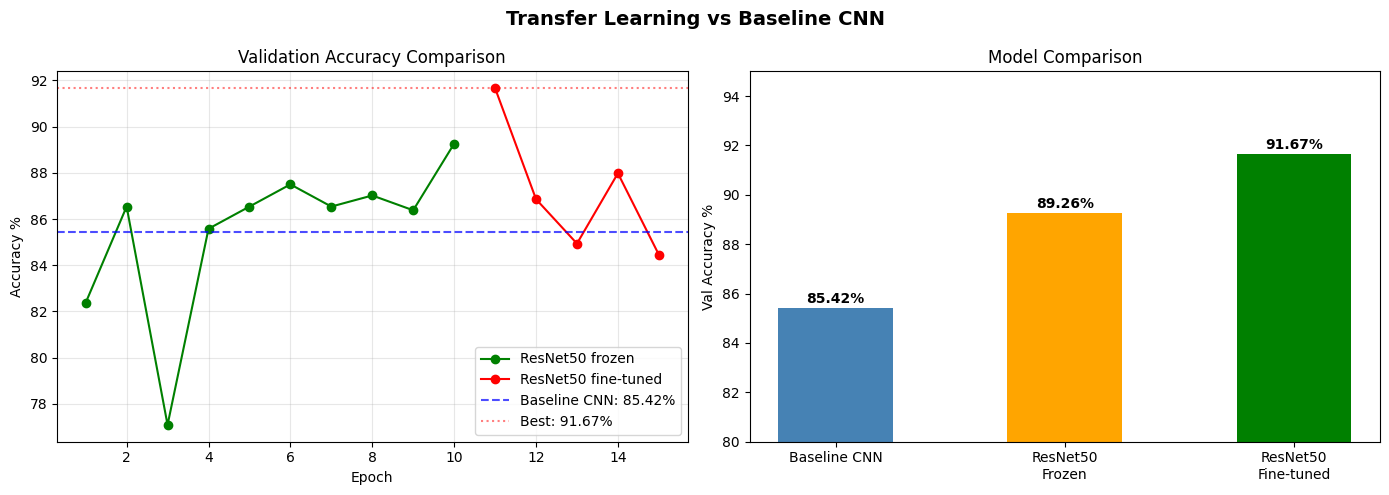

Improvement over baseline: 6.25 percentage points


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_resnet = range(1, 11)
epochs_ft     = range(11, 16)

# Accuracy comparison
axes[0].plot(epochs_resnet, history_resnet['val_acc'], 'g-o', label='ResNet50 frozen')
axes[0].plot(epochs_ft,     history_ft['val_acc'],     'r-o', label='ResNet50 fine-tuned')
axes[0].axhline(y=85.42, color='blue', linestyle='--', alpha=0.7, label='Baseline CNN: 85.42%')
axes[0].axhline(y=91.67, color='red',  linestyle=':',  alpha=0.5, label='Best: 91.67%')
axes[0].set_title('Validation Accuracy Comparison')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy %')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Bar chart comparison
models_list = ['Baseline CNN', 'ResNet50\nFrozen', 'ResNet50\nFine-tuned']
accuracies  = [85.42, 89.26, 91.67]
colors_list = ['steelblue', 'orange', 'green']

bars = axes[1].bar(models_list, accuracies, color=colors_list, width=0.5)
axes[1].set_ylim(80, 95)
axes[1].set_title('Model Comparison')
axes[1].set_ylabel('Val Accuracy %')
for bar, acc in zip(bars, accuracies):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{acc}%', ha='center', fontweight='bold')

plt.suptitle('Transfer Learning vs Baseline CNN', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Improvement over baseline:", round(91.67 - 85.42, 2), "percentage points")